In [153]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import style
np.random.seed(42)


In [155]:
def zscore_normmalise(X):
  mean=np.mean(X,axis=0)
  std_dev=np.std(X,axis=0)
  X_norm=(X-mean)/std_dev
  return X_norm,mean,std_dev



In [156]:
def one_hot(y):
  m=y.shape[0]

  # If y is 0-indexed (0 to N-1), number of classes is max_label + 1
  n=np.max(y)+1
  y_one_hot = np.zeros((m,n))
  for i in range(m):
    y_one_hot[i,y[i]]=1
  return y_one_hot

In [157]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

def softmax(x):
  # Subtract the maximum value for numerical stability
  exp_x = np.exp(x - np.max(x, axis=0, keepdims=True))
  return exp_x / np.sum(exp_x, axis=0, keepdims=True)

def relu(x):
  return np.maximum(0,x)

def tanh(X):
  return np.tanh(X)

def relu_derivative(x):
  return (x > 0).astype(float)
def tanh_derivative(x):
  return 1-np.tanh(x)**2

In [158]:
def initialize_parameters(layer_dims):
  parameters={}
  L=len(layer_dims)
  for l in range(1,L):
    parameters["w"+str(l)]=np.random.randn(layer_dims[l],layer_dims[l-1])*np.sqrt(2/layer_dims[l-1])
    parameters["b"+str(l)]=np.zeros((layer_dims[l],1))
  return parameters


In [159]:
def forward_propagation(X,parameters,activation):
  L=len(parameters)//2
  cache = {"A0":X}
  for l in range(1,L):
    Z=parameters["w"+str(l)]@cache["A"+str(l-1)]+parameters["b"+str(l)]
    cache["Z"+str(l)]=Z
    if activation=="relu":
      cache["A"+str(l)]=relu(Z)
    else :
      cache["A"+str(l)]=tanh(Z)


  ZL=parameters["w"+str(L)]@cache["A"+str(L-1)]+parameters["b"+str(L)]
  cache["Z"+str(L)]=ZL
  # For regression (single output neuron), use linear activation
  if ZL.shape[0]==1:
    AL=ZL
  # For multi-class classification, use softmax
  else:
    AL=softmax(ZL)
  cache["A"+str(L)]=AL
  return AL,cache

In [160]:
def cost(AL,Y):
  m=Y.shape[1]

  # If output layer has single neuron, assume regression (MSE loss)
  if Y.shape[0]==1:
    cost=1/m*np.sum((AL-Y)**2) # Mean Squared Error
  # Otherwise (multi-class classification), use cross-entropy loss
  else:
    cost=-1/m*np.sum(Y*np.log(AL + 1e-9))  # epsilon for numerical stability

  cost=np.squeeze(cost)
  return cost

In [161]:
def back_propagation(AL,Y,cache,parameters,activation):
  L=len(parameters)//2
  grads={}
  m=Y.shape[1]
  grads["dz"+str(L)]=AL-Y
  grads["dw"+str(L)]=1/m*grads["dz"+str(L)]@cache["A"+str(L-1)].T
  grads["db"+str(L)]=1/m*np.sum(grads["dz"+str(L)],axis=1,keepdims=True)
  for l in range(L-1,0,-1):
    if activation=="relu":
      dA=relu_derivative(cache["Z"+str(l)])
    else:
      dA=tanh_derivative(cache["Z"+str(l)])
    grads["dz"+str(l)]=parameters["w"+str(l+1)].T@grads["dz"+str(l+1)]*dA
    grads["dw"+str(l)]=1/m*grads["dz"+str(l)]@cache["A"+str(l-1)].T
    grads["db"+str(l)]=1/m*np.sum(grads["dz"+str(l)],axis=1,keepdims=True)
  return grads

In [162]:
def update_parameters(parameters,grades,alpha):
  L=len(parameters)//2
  for l in range(1,L+1):
    parameters["w"+str(l)]=parameters["w"+str(l)]-alpha*grades["dw"+str(l)]
    parameters["b"+str(l)]=parameters["b"+str(l)]-alpha*grades["db"+str(l)]
  return parameters

In [163]:
def model(X,y,X_val,Y_val,layer_dims,alpha,iteration,activation="relu"):
  parameters= initialize_parameters(layer_dims)
  cost_list=[]
  for i in range(iteration):
    AL,cache=forward_propagation(X,parameters,activation)
    j=cost(AL,y)

    grads=back_propagation(AL,y,cache,parameters,activation)
    parameters=update_parameters(parameters,grads,alpha)
    cost_list.append(j)

    if i % (iteration //10) ==0:
      print(
          f"Iter {i:4d} | cost : {j:4f} |"


      )
  return parameters,cost_list

In [164]:
def cost_vs_iteration(j):
  iterations=list(range(1,len(j)+1))
  style.use('ggplot')
  plt.plot(iterations,j)
  plt.title('Cost vs Iteration')
  plt.xlabel('Iterations')
  plt.ylabel('Cost')
  plt.show()

In [165]:
def predict(X,parameters,activation):
  AL,cache=forward_propagation(X,parameters,activation)
  return np.argmax(AL,axis=0)

In [166]:
def macro_f1_score(y_true,y_pred):
  classes=np.unique(y_true)
  f1_score=0
  for c in classes:
    tp=np.sum((y_true==c)&(y_pred==c))
    fp=np.sum((y_true!=c)&(y_pred==c))
    fn=np.sum((y_true==c)&(y_pred!=c))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    if (precision + recall) > 0:
      f1_score+=2*precision*recall/(precision+recall)
    else:
      f1_score+=0

  return f1_score/len(classes)

In [167]:

def r2_score(y_true,y_pred):
  y_mean=np.mean(y_true)
  ss_tot=np.sum((y_true-y_mean)**2)
  ss_res=np.sum((y_true-y_pred)**2)
  r2=1-(ss_res/ss_tot)
  return r2


**Data Loading**

In [168]:
train_df=pd.read_csv('/content/drive/MyDrive/WOC/train_nn.csv')
test_df=pd.read_csv('/content/drive/MyDrive/WOC/test_nn.csv')
train_df

,Unnamed: 0,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,...,F_13,F_14,F_15,F_16,F_17,F_18,F_19,F_20,target_cls,target_reg
0,0,4,7,5,5,4,6,7,3,7,...,3,8,4,8,15.70,8.75,4.69,32.7,5,7.39
1,1,4,7,6,5,5,6,8,3,7,...,3,8,4,7,18.84,8.75,4.69,32.7,5,7.83
2,2,3,5,4,3,3,7,8,5,5,...,5,9,2,6,12.56,6.25,3.35,52.5,14,6.28
3,3,4,10,6,7,6,5,7,5,7,...,3,8,6,9,18.84,8.75,6.70,54.0,11,8.74
4,4,4,10,6,8,4,8,11,2,3,...,3,11,1,8,18.84,3.75,6.70,23.4,22,9.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,15995,5,11,4,6,3,7,7,4,3,...,3,10,8,7,12.56,3.75,7.37,44.1,7,8.49
15996,15996,3,7,5,5,4,9,11,6,4,...,2,8,6,4,15.70,5.00,4.69,63.3,26,7.84
15997,15997,3,4,6,3,2,9,6,2,8,...,2,7,3,9,18.84,10.00,2.68,21.6,24,5.25
15998,15998,3,8,4,6,2,7,8,0,8,...,0,8,1,7,12.56,10.00,5.36,2.4,9,5.91


In [169]:
train_df.describe()

,Unnamed: 0,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,...,F_13,F_14,F_15,F_16,F_17,F_18,F_19,F_20,target_cls,target_reg
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,...,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,7999.500000,4.024687,7.042125,5.121250,5.377063,3.506250,6.897625,7.494375,4.635063,5.180125,...,3.045437,8.334500,3.690937,7.802500,16.080725,6.475156,4.718224,49.390275,13.464438,7.273268
std,4618.946489,1.911820,3.303583,2.016384,2.266237,2.190037,2.030739,2.325872,2.710967,2.391477,...,2.332158,1.543295,2.566092,1.616913,6.331444,2.989346,2.213400,27.644889,7.517107,1.943970
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.900000,1.000000,0.070000
25%,3999.750000,3.000000,5.000000,4.000000,4.000000,2.000000,6.000000,6.000000,3.000000,4.000000,...,1.000000,8.000000,2.000000,7.000000,12.560000,5.000000,3.350000,32.100000,7.000000,6.000000
50%,7999.500000,4.000000,7.000000,5.000000,6.000000,3.000000,7.000000,7.000000,4.000000,5.000000,...,3.000000,8.000000,3.000000,8.000000,15.700000,6.250000,4.690000,43.800000,13.000000,7.360000
75%,11999.250000,5.000000,9.000000,6.000000,7.000000,5.000000,8.000000,9.000000,6.000000,7.000000,...,4.000000,9.000000,5.000000,8.000000,18.840000,8.750000,6.030000,63.300000,20.000000,8.630000
max,15999.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,...,15.000000,15.000000,15.000000,15.000000,47.100000,18.750000,10.050000,156.300000,26.000000,14.990000


In [170]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  16000 non-null  int64  
 1   F_1         16000 non-null  int64  
 2   F_2         16000 non-null  int64  
 3   F_3         16000 non-null  int64  
 4   F_4         16000 non-null  int64  
 5   F_5         16000 non-null  int64  
 6   F_6         16000 non-null  int64  
 7   F_7         16000 non-null  int64  
 8   F_8         16000 non-null  int64  
 9   F_9         16000 non-null  int64  
 10  F_10        16000 non-null  int64  
 11  F_11        16000 non-null  int64  
 12  F_12        16000 non-null  int64  
 13  F_13        16000 non-null  int64  
 14  F_14        16000 non-null  int64  
 15  F_15        16000 non-null  int64  
 16  F_16        16000 non-null  int64  
 17  F_17        16000 non-null  float64
 18  F_18        16000 non-null  float64
 19  F_19        16000 non-nul

In [171]:
train_df=train_df.drop(columns=['Unnamed: 0'])
test_df=test_df.drop(columns=['Unnamed: 0'])

In [172]:
X=train_df.drop(columns=["target_cls","target_reg"]).to_numpy()
y_cls=train_df["target_cls"].to_numpy()
y_reg=train_df["target_reg"].to_numpy().reshape(-1,1)



In [173]:
# Split data
X_train_data = X[:12000,:]
y_cls_train_data = y_cls[:12000]
y_reg_train_data = y_reg[:12000]
X_val_data = X[12000:,:]
y_cls_val_data = y_cls[12000:]
y_reg_val_data = y_reg[12000:]

# Normalize X_train and X_val
X_train_norm, mean, std_dev = zscore_normmalise(X_train_data)
X_val_norm = (X_val_data - mean) / std_dev

# Transpose X data to (features, samples)
X_train_processed = X_train_norm.T
X_val_processed = X_val_norm.T

# One-hot encode and transpose y_cls data to (classes, samples)
# Subtract 1 to make labels 0-indexed before one-hot encoding
y_cls_train_processed = one_hot(y_cls_train_data - 1).T
y_cls_val_processed = one_hot(y_cls_val_data - 1).T

**Classification Model Training**

In [ ]:
layer_dims=[X_train_processed.shape[0],128,64,y_cls_train_processed.shape[0]]
parameters_cls,cost_cls=model(X_train_processed,y_cls_train_processed,X_val_processed,y_cls_val_processed,layer_dims,alpha=0.02,iteration=5000,activation="relu")

Iter    0 | cost : 4.039145 |
Iter  500 | cost : 1.186097 |
Iter 1000 | cost : 0.858271 |
Iter 1500 | cost : 0.698009 |
Iter 2000 | cost : 0.597734 |
Iter 2500 | cost : 0.526964 |
Iter 3000 | cost : 0.472518 |


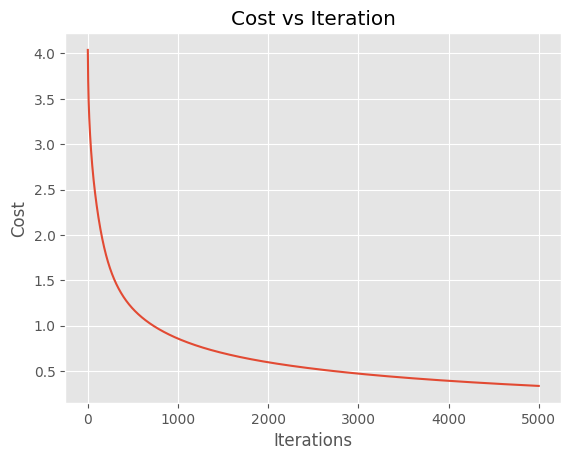

In [190]:
cost_vs_iteration(cost_cls)

In [191]:
AL_train, cache_train = forward_propagation(X_train_processed, parameters_cls, activation="relu")
y_cls_train_pred = np.argmax(AL_train, axis=0)
f1_train = macro_f1_score(y_cls_train_data, y_cls_train_pred + 1)

print(f"Macro F1 Score (Train): {f1_train}")

Macro F1 Score (Train): 0.905732960712467


In [192]:
AL_val,cache_val=forward_propagation(X_val_processed,parameters_cls,activation="relu")
y_cls_pred=np.argmax(AL_val,axis=0)
f1=macro_f1_score(y_cls_val_data,y_cls_pred + 1)

print(f"Macro F1 Score(val): {f1}")

Macro F1 Score(val): 0.8799717986332857


**Regression Model Training**

In [193]:
y_reg_train_norm,mean2,std_dev2=zscore_normmalise(y_reg_train_data)
y_reg_val_norm=(y_reg_val_data-mean2)/std_dev2

In [194]:
y_reg_train_processed=y_reg_train_norm.T
y_reg_val_processed=y_reg_val_norm.T

In [195]:
layer_dims_reg=[X_train_processed.shape[0],128,64,1]
parameters_reg,cost_reg=model(X_train_processed,y_reg_train_processed,X_val_processed,y_reg_val_processed,layer_dims_reg,alpha=0.02,iteration=3000,activation="relu")

Iter    0 | cost : 1.842455 |
Iter  300 | cost : 0.034756 |
Iter  600 | cost : 0.020540 |
Iter  900 | cost : 0.014995 |
Iter 1200 | cost : 0.011976 |
Iter 1500 | cost : 0.010024 |
Iter 1800 | cost : 0.008666 |
Iter 2100 | cost : 0.007663 |
Iter 2400 | cost : 0.006887 |
Iter 2700 | cost : 0.006269 |


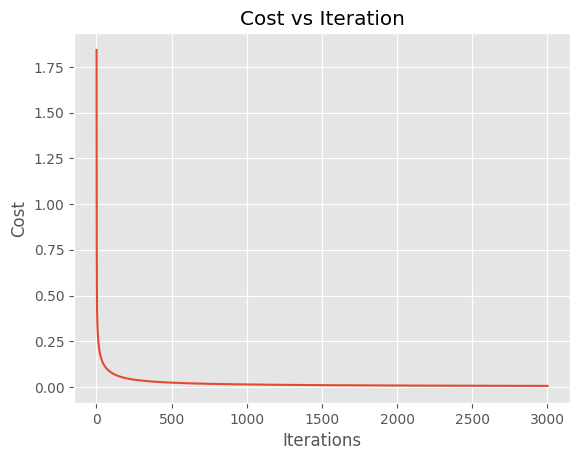

In [196]:
cost_vs_iteration(cost_reg)

In [197]:
y_pred_train_norm, _ = forward_propagation(X_train_processed, parameters_reg, activation="relu")

# Transpose y_pred_train_norm to match the shape of y_reg_train_data before denormalization
y_reg_train_pred = y_pred_train_norm.T * std_dev2 + mean2
r2_train = r2_score(y_reg_train_data, y_reg_train_pred)
print(f"R2 Score (Train): {r2_train}")

R2 Score (Train): 0.994235327599844


In [198]:
y_pred_norm,_=forward_propagation(X_val_processed,parameters_reg,activation="relu")

# Transpose y_pred_norm to match the shape of y_reg_val_data before denormalization
y_reg_pred = y_pred_norm.T * std_dev2 + mean2
r2=r2_score(y_reg_val_data,y_reg_pred)
print(f"R2 Score (val): {r2}")

R2 Score (val): 0.9935865779355634


**Generating Predictions on Test Data**

In [199]:
X_test_data = test_df.to_numpy()
X_test_norm = (X_test_data - mean) / std_dev
X_test_processed = X_test_norm.T

In [200]:
# Predict classification labels for test data
y_cls_test_pred = predict(X_test_processed, parameters_cls, activation="relu")+1
y_cls_test_pred.reshape(-1,1)


array([[26],
       [18],
       [ 1],
       ...,
       [17],
       [ 8],
       [25]])

In [201]:
# Predict regression values for test data
y_reg_test_pred_norm, _ = forward_propagation(X_test_processed, parameters_reg, activation="relu")

# Denormalize the regression predictions
y_reg_test_pred = y_reg_test_pred_norm.T * std_dev2 + mean2
y_reg_test_pred


array([[ 7.14228478],
       [10.4582179 ],
       [ 4.54655452],
       ...,
       [ 8.06961271],
       [10.03680575],
       [ 7.15808295]])

In [202]:
predi=np.concatenate((y_cls_test_pred.reshape(-1,1),y_reg_test_pred),axis=1)
predi

array([[26.        ,  7.14228478],
       [18.        , 10.4582179 ],
       [ 1.        ,  4.54655452],
       ...,
       [17.        ,  8.06961271],
       [ 8.        , 10.03680575],
       [25.        ,  7.15808295]])

In [203]:
df_pred=pd.DataFrame(predi,columns=["target_cls","target_reg"])
df_pred

,target_cls,target_reg
0,26.0,7.142285
1,18.0,10.458218
2,1.0,4.546555
3,5.0,5.360804
4,17.0,7.599415
...,...,...
3995,19.0,7.957816
3996,20.0,6.271477
3997,17.0,8.069613
3998,8.0,10.036806


In [204]:
df_pred.to_csv('NN_prediction.csv',index=False)